1.Importing the libraries

In [3]:
import pandas as pd

2.Importing the Dataset

In [6]:
data = pd.read_csv(r'C:\Users\iprat\OneDrive\Documents\heart.csv')

3.Taking care of missing value

In [9]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

4. Taking Care of duplicate Values

In [12]:
data_dup = data.duplicated().any()

In [14]:
data_dup

True

In [16]:
data = data.drop_duplicates()

In [18]:
data_dup = data.duplicated().any()

In [20]:
data_dup

False

In [22]:
data_dup

False

5.Data Processing

In [25]:
cate_val=[]
cont_val=[]

for column in data.columns:
    if data[column].nunique()  <= 10:
        cate_val.append(column)
    else:
        cont_val.append(column)

In [27]:
cate_val

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

In [29]:
cont_val

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

6.Encoding Categorical Data

In [32]:
cate_val

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

In [34]:
data['cp'].unique()

array([0, 1, 2, 3], dtype=int64)

In [36]:
cate_val.remove('sex')
cate_val.remove('target')
data=pd.get_dummies(data,columns=cate_val,drop_first=True)

In [38]:
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,1,125,212,168,1.0,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,1,140,203,155,3.1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,1,145,174,125,2.6,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,1,148,203,161,0.0,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,0,138,294,106,1.9,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


7.Feature Scaling

In [41]:
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,1,125,212,168,1.0,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,1,140,203,155,3.1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,1,145,174,125,2.6,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,1,148,203,161,0.0,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,0,138,294,106,1.9,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [43]:
from sklearn.preprocessing import StandardScaler

In [45]:
st = StandardScaler()
data[cont_val] = st.fit_transform(data[cont_val])

In [47]:
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,-0.667728,0.806035,-0.037124,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,-0.157260,1,0.478910,-0.841918,0.237495,1.773958,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,1.724733,1,0.764066,-1.403197,-1.074521,1.342748,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,0.728383,1,0.935159,-0.841918,0.499898,-0.899544,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,0.839089,0,0.364848,0.919336,-1.905464,0.739054,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


8.Splitting The Dataset Into The Training Set And Test Set

In [50]:
X = data.drop('target' ,axis=1)

In [52]:
y = data['target']

In [54]:
from sklearn.model_selection import train_test_split

In [56]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
y_test

245    1
349    0
135    0
389    1
66     1
      ..
402    1
123    1
739    0
274    1
256    1
Name: target, Length: 61, dtype: int64

9.Logistic Regression

In [61]:
data.head()

,age,sex,trestbps,chol,thalach,oldpeak,target,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,-0.667728,0.806035,-0.037124,0,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,-0.157260,1,0.478910,-0.841918,0.237495,1.773958,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,1.724733,1,0.764066,-1.403197,-1.074521,1.342748,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,0.728383,1,0.935159,-0.841918,0.499898,-0.899544,0,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,0.839089,0,0.364848,0.919336,-1.905464,0.739054,0,False,False,False,...,False,True,False,False,False,True,False,False,True,False


In [63]:
from sklearn.linear_model import LogisticRegression

In [65]:
log = LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [67]:
y_pred1 = log.predict(X_test)

In [69]:
from sklearn.metrics import accuracy_score

In [71]:
accuracy_score(y_test,y_pred1)

0.7868852459016393

10.SVC

In [74]:
from sklearn import svm

In [76]:
svm = svm.SVC()

In [78]:
svm.fit(X_train,y_train)

SVC()

In [80]:
y_pred2 = svm.predict(X_test)

In [82]:
accuracy_score(y_test,y_pred2)

0.8032786885245902

11.KNeighbors Classifier

In [87]:
from sklearn.neighbors import KNeighborsClassifier

In [89]:
knn = KNeighborsClassifier()

In [91]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [93]:
y_pred3=knn.predict(X_test)

In [95]:
accuracy_score(y_test,y_pred3)

0.7377049180327869

In [97]:
score = []

for k in range(1,40):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    score.append(accuracy_score(y_test,y_pred))

In [99]:
score

[0.7213114754098361,
 0.8032786885245902,
 0.7049180327868853,
 0.7049180327868853,
 0.7377049180327869,
 0.8032786885245902,
 0.7868852459016393,
 0.8032786885245902,
 0.7704918032786885,
 0.7540983606557377,
 0.7704918032786885,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7540983606557377,
 0.7704918032786885,
 0.7540983606557377,
 0.7540983606557377,
 0.7377049180327869,
 0.7540983606557377,
 0.7377049180327869,
 0.7213114754098361,
 0.7377049180327869,
 0.7377049180327869,
 0.7213114754098361,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869]

In [105]:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    score.append(accuracy_score(y_test,y_pred))

Non-Linear ML Algorithms

In [108]:
data = pd.read_csv(r'C:\Users\iprat\OneDrive\Documents\heart.csv')

In [110]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [112]:
data = data.drop_duplicates()

In [114]:
data.shape

(302, 14)

In [116]:
X = data.drop('target', axis=1)
y = data['target']

In [118]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

12.Decision Tree Classifier

In [121]:
from sklearn.tree import DecisionTreeClassifier

In [123]:
dt = DecisionTreeClassifier()

In [125]:
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [127]:
y_pred4= dt.predict(X_test)

In [129]:
accuracy_score(y_test,y_pred)

0.7377049180327869

13.Random Forest Classifier

In [132]:
from sklearn.ensemble import RandomForestClassifier

In [134]:
rf = RandomForestClassifier()

In [136]:
rf = RandomForestClassifier(random_state=42)

In [138]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [140]:
y_pred5 = rf.predict(X_test)

In [142]:
accuracy_score(y_test,y_pred5)

0.8360655737704918

14.Gradient Boosting Classifier

In [145]:
from sklearn.ensemble import GradientBoostingClassifier

In [147]:
gbc = GradientBoostingClassifier()

In [149]:
gbc.fit(X_train,y_train)

GradientBoostingClassifier()

In [151]:
y_pred6 = gbc.predict(X_test)

In [153]:
accuracy_score(y_test,y_pred6)

0.8032786885245902

In [155]:
final_data = pd.DataFrame({
    'Models': ['LR', 'SVM', 'KNN', 'DT', 'RF','GB'],
    'ACC': [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3),
        accuracy_score(y_test, y_pred4),
        accuracy_score(y_test, y_pred5),
        accuracy_score(y_test, y_pred5)
    ]
})

In [157]:
final_data

,Models,ACC
0,LR,0.786885
1,SVM,0.803279
2,KNN,0.737705
3,DT,0.704918
4,RF,0.836066
5,GB,0.836066


In [159]:
import seaborn as sns

<Axes: xlabel='Models', ylabel='ACC'>

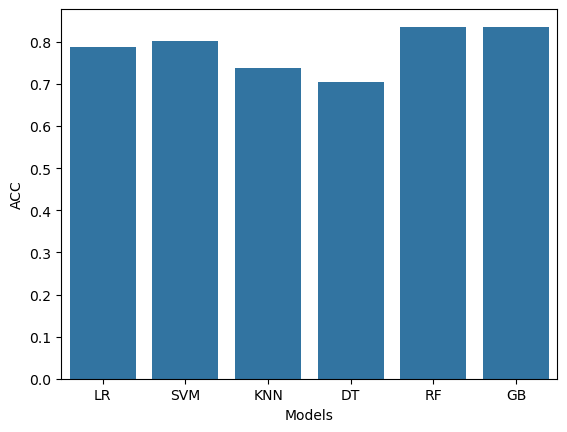

In [161]:
sns.barplot(x='Models', y='ACC', data=final_data)

In [163]:
X = data.drop('target',axis=1)
y = data['target']

In [165]:
X.shape

(302, 13)

In [167]:
from sklearn.ensemble import RandomForestClassifier

In [169]:
rf = RandomForestClassifier()
rf.fit(X,y)

RandomForestClassifier()

In [171]:
RandomForestClassifier()

RandomForestClassifier()

15.Prediction On New Data

In [174]:
import pandas as pd

In [176]:
new_data = pd.DataFrame({
    'age':52,
    'sex':1,
    'cp':0,
    'trestbps':125,
    'chol':212,
    'fbs':0,
    'restecg':1,
    'thalach':168,
    'exang':0,
    'oldpeak':1.0,
    'slope':2,
    'ca':2,
    'thal':3,
},index=[0])

In [178]:
new_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3


In [180]:
p = rf.predict(new_data)
if p[0] == 0:
    print('Congratulations! Your heart is fine. Stay healthy.')
else:
    print("There is a possibility that your heart is at risk!")

Congratulations! Your heart is fine. Stay healthy.


16.Gave Model Using Joblib

In [183]:
import joblib

In [185]:
joblib.dump(rf,'model_joblib_heart')

['model_joblib_heart']

In [187]:
model = joblib.load('model_joblib_heart')

In [189]:
model.predict(new_data)

array([0], dtype=int64)

GUI

In [192]:
from tkinter import *
import joblib

In [202]:
from tkinter import *
import joblib
import numpy as np

def show_entry_fields():
    p1 = int(e1.get())
    p2 = int(e2.get())
    p3 = int(e3.get())
    p4 = int(e4.get())
    p5 = int(e5.get())
    p6 = int(e6.get())
    p7 = int(e7.get())
    p8 = int(e8.get())
    p9 = int(e9.get())
    p10 = float(e10.get())
    p11 = int(e11.get())
    p12 = int(e12.get())
    p13 = int(e13.get())
    
    model = joblib.load('model_joblib_heart')
    result = model.predict([[p1, p2, p3, p4, p5, p6, p7, p8, p9, p10, p11, p12, p13]])

    if result[0] == 0:
        Label(master, text="Congratulations! Your heart is fine. Stay Healthy!").grid(row=31)
    else:
        Label(master, text="There is a possibility that your heart is at risk. Please consult a doctor!").grid(row=31)

master = Tk()
master.title("Heart Disease Prediction")

Label(master, text="Heart Disease Prediction", bg="black", fg="white").grid(row=0, columnspan=2)

Label(master, text="Enter Your Age").grid(row=1)
Label(master, text="Male or Female [1/0]").grid(row=2)
Label(master, text="Enter Value of CP").grid(row=3)
Label(master, text="Enter Value of trestbps").grid(row=4)
Label(master, text="Enter Value of chol").grid(row=5)
Label(master, text="Enter Value of fbs").grid(row=6)
Label(master, text="Enter Value of restecg").grid(row=7)
Label(master, text="Enter Value of thalach").grid(row=8)
Label(master, text="Enter Value of exang").grid(row=9)
Label(master, text="Enter Value of oldpeak").grid(row=10)
Label(master, text="Enter Value of slope").grid(row=11)
Label(master, text="Enter Value of ca").grid(row=12)
Label(master, text="Enter Value of thal").grid(row=13)

# Entry fields
e1 = Entry(master)
e2 = Entry(master)
e3 = Entry(master)
e4 = Entry(master)
e5 = Entry(master)
e6 = Entry(master)
e7 = Entry(master)
e8 = Entry(master)
e9 = Entry(master)
e10 = Entry(master)
e11 = Entry(master)
e12 = Entry(master)
e13 = Entry(master)

e1.grid(row=1, column=1)
e2.grid(row=2, column=1)
e3.grid(row=3, column=1)
e4.grid(row=4, column=1)
e5.grid(row=5, column=1)
e6.grid(row=6, column=1)
e7.grid(row=7, column=1)
e8.grid(row=8, column=1)
e9.grid(row=9, column=1)
e10.grid(row=10, column=1)
e11.grid(row=11, column=1)
e12.grid(row=12, column=1)
e13.grid(row=13, column=1)

Button(master, text='Predict', command=show_entry_fields).grid(row=30, column=1)

master.mainloop()


